In [36]:
# importing required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import randint, uniform

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [37]:
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 42
CSV_PATH = "../data/heart.csv"
TARGET_COL = "target"
print(CSV_PATH)

../data/heart.csv


In [38]:
df = pd.read_csv(CSV_PATH)
print("Shape:", df.shape)
df.head()

Shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [40]:
num_features = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak',
    'ca'
]

categorical_features = [
    'sex',
    'cp',
    'fbs',
    'restecg',
    'exang',
    'slope',
    'thal',
    'target'
]

In [41]:
for col in df.columns:
    print(df[col].value_counts().head(10))

age
58    68
57    57
54    53
59    46
52    43
56    39
51    39
62    37
60    37
44    36
Name: count, dtype: int64
sex
1    713
0    312
Name: count, dtype: int64
cp
0    497
2    284
1    167
3     77
Name: count, dtype: int64
trestbps
120    128
130    123
140    107
110     64
150     55
138     45
128     39
125     38
160     36
112     30
Name: count, dtype: int64
chol
204    21
234    21
197    19
212    18
254    17
269    16
240    14
282    14
177    14
226    13
Name: count, dtype: int64
fbs
0    872
1    153
Name: count, dtype: int64
restecg
1    513
0    497
2     15
Name: count, dtype: int64
thalach
162    35
160    31
163    29
152    28
173    28
132    26
144    26
125    25
150    25
143    23
Name: count, dtype: int64
exang
0    680
1    345
Name: count, dtype: int64
oldpeak
0.000    329
1.200     58
1.000     51
0.600     47
0.800     44
1.400     44
1.600     37
0.200     37
1.800     36
2.000     32
Name: count, dtype: int64
slope
1    482
2    469
0     74
N

In [42]:
# check for duplicates
duplicate_mask = df.duplicated()
num_duplicates = duplicate_mask.sum()
print("Number of duplicates:", num_duplicates)

Number of duplicates: 723


In [43]:
# Target distribution
print(df[TARGET_COL].value_counts())
print("-"*50)
print(df[TARGET_COL].value_counts(normalize=True))

target
1    526
0    499
Name: count, dtype: int64
--------------------------------------------------
target
1   0.513
0   0.487
Name: proportion, dtype: float64


In [44]:
df[num_features].describe()

,age,trestbps,chol,thalach,oldpeak,ca
count,1025.000,1025.000,1025.000,1025.000,1025.000,1025.000
mean,54.434,131.612,246.000,149.114,1.072,0.754
std,9.072,17.517,51.593,23.006,1.175,1.031
min,29.000,94.000,126.000,71.000,0.000,0.000
25%,48.000,120.000,211.000,132.000,0.000,0.000
50%,56.000,130.000,240.000,152.000,0.800,0.000
75%,61.000,140.000,275.000,166.000,1.800,1.000
max,77.000,200.000,564.000,202.000,6.200,4.000


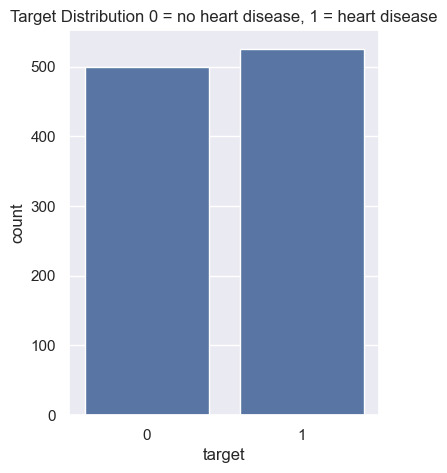

In [45]:
# Target visualization 
plt.figure(figsize=(4,5))
sns.countplot(x=TARGET_COL, data=df)
plt.title("Target Distribution 0 = no heart disease, 1 = heart disease")
plt.show()

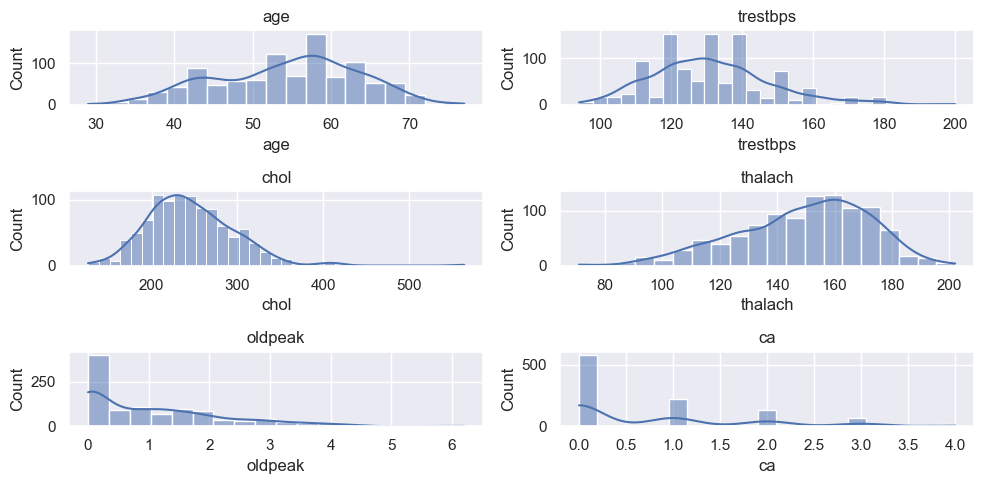

In [46]:
# histoplot for distribution - numerical features
fig, axes = plt.subplots(3,2, figsize = (10,5))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.histplot(df[col], kde=True ,ax=axes[i])
    plt.title(col)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

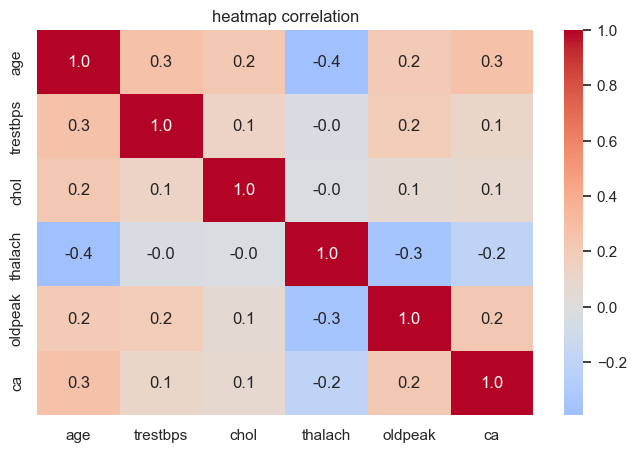

In [47]:
plt.figure(figsize=(8,5))
sns.heatmap(
    df[num_features].corr(),
    cmap='coolwarm',
    annot=True,
    center=0,
    fmt = '.1f'
)

plt.title('heatmap correlation')
plt.show()

In [48]:
X = df.drop(columns = TARGET_COL)
y = df[TARGET_COL]

row_signature = pd.util.hash_pandas_object(X, index=False)

In [49]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.15,
    random_state=42
)

train_idx, test_idx =next(
    gss.split(X, y, groups=row_signature)
)

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

In [50]:
print("Shape Train X:", X_train.shape)
print("Shape Test X:", X_test.shape)

Shape Train X: (869, 13)
Shape Test X: (156, 13)


In [51]:
pipe = Pipeline(
    [('scaler', StandardScaler()), ('model', LogisticRegression())]
)

base_pipeline = pipe.fit(X_train, y_train)

In [52]:
y_train_pred = base_pipeline.predict(X_train)
y_test_pred = base_pipeline.predict(X_test)

In [53]:
from sklearn.metrics import accuracy_score, classification_report, recall_score, f1_score

In [54]:
train_acc = accuracy_score(y_train, y_train_pred) * 100
test_acc = accuracy_score(y_test, y_test_pred) * 100

# accuracy
print("Test accuracy:", test_acc)
print("Train accuracy:", train_acc)

Test accuracy: 83.33333333333334
Train accuracy: 84.23475258918297


In [55]:
# classifciattion report
print("Test Classification:")
print(classification_report(y_test, y_test_pred))

print("-" * 50)

print("Train Classification:")
print(classification_report(y_train, y_train_pred))

Test Classification:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79        69
           1       0.80      0.93      0.86        87

    accuracy                           0.83       156
   macro avg       0.85      0.82      0.83       156
weighted avg       0.84      0.83      0.83       156

--------------------------------------------------
Train Classification:
              precision    recall  f1-score   support

           0       0.88      0.79      0.83       430
           1       0.81      0.89      0.85       439

    accuracy                           0.84       869
   macro avg       0.85      0.84      0.84       869
weighted avg       0.85      0.84      0.84       869



In [56]:
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Support Vector Machine": SVC(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier()
}

In [57]:
groups = pd.util.hash_pandas_object(X_train, index = False)

k = 5
cv = StratifiedGroupKFold(n_splits=k, shuffle=True, random_state=42)

In [58]:
for name, model in models.items():
    recall_scores = []
    f1_scores = []

    for tr_idx, te_idx in cv.split(X_train, y_train, groups=groups):
        X_tr, X_te = X_train.iloc[tr_idx], X_train.iloc[te_idx]
        y_tr, y_te = y_train.iloc[tr_idx], y_train.iloc[te_idx]

        pipeline = Pipeline(
            steps=[
                ("scaler", StandardScaler()),
                ("model", model)
            ]
        )
        
        
        pipeline.fit(X_tr, y_tr)
        pred = pipeline.predict(X_te)
        
        recall_scores.append(round(recall_score(y_te, pred), 2))
        f1_scores.append(round(f1_score(y_te, pred), 2))

    print("Model:", model)
    print("Recall values:", recall_scores)
    print("F1 values:", f1_scores)
    print("\nCV Recall mean:", round(float(np.mean(recall_scores)), 4))
    print("CV F1 Score mean:", round(float(np.mean(f1_scores)), 4))


Model: LogisticRegression(random_state=42)
Recall values: [0.9, 0.75, 0.93, 0.89, 0.82]
F1 values: [0.87, 0.75, 0.91, 0.82, 0.75]

CV Recall mean: 0.858
CV F1 Score mean: 0.82
Model: SVC(random_state=42)
Recall values: [0.79, 0.72, 0.82, 0.96, 0.72]
F1 values: [0.76, 0.76, 0.84, 0.83, 0.69]

CV Recall mean: 0.802
CV F1 Score mean: 0.776
Model: RandomForestClassifier(random_state=42)
Recall values: [0.93, 0.82, 0.9, 0.92, 0.82]
F1 values: [0.88, 0.81, 0.87, 0.87, 0.75]

CV Recall mean: 0.878
CV F1 Score mean: 0.836
Model: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_thresho